# TerraMind Embedding Comparison
Compare embeddings from PhiSat-2 triplets (real, simulated, Sentinel-2) using cosine similarity.

## 1. Import Libraries

In [1]:
import torch
import torch.nn.functional as F
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load TerraMind Model

In [2]:
from terratorch.tasks import SemanticSegmentationTask
from terra_sat_drift.data_simulation.phisat2_constants import S2_BANDS_NAMES, S2_BANDS

# Load pre-trained TerraMind model
# print("Loading pre-trained TerraMind model...")
# checkpoint_path = Path("/shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods_simulated/checkpoints_stage1/best-val_mIoU.ckpt")

# if checkpoint_path.exists():
#     model = SemanticSegmentationTask.load_from_checkpoint(str(checkpoint_path))
#     print(f"✓ Model loaded from checkpoint: {checkpoint_path}")
# else:
#     print(f"⚠ Checkpoint not found, creating fresh model...")
    # Create a fresh model if checkpoint doesn't exist
from terratorch import BACKBONE_REGISTRY

layers_to_probe = [1, 3, 4, 5]
    
backbone_name = "terramind_v1_small"
model_args = {
    "backbone": backbone_name,
    "backbone_pretrained": True,
    "backbone_modalities": ["S2L1C"],
    "backbone_bands": {"S2L1C": S2_BANDS},
    "decoder": "IdentityDecoder",
    "necks": [
        {"name": "SelectIndices", "indices": layers_to_probe},
        {"name": "ReshapeTokensToImage", "remove_cls_token": False},
        {"name": "LearnedInterpolateToPyramidal"},
    ],
        "num_classes": 2,
}
task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,
    freeze_backbone=True,
    lr=1e-4,
)
print("model created with pretrained backbone")

task.model.to(device)
task.model.eval()
print("Model ready for inference")
print(task.model)
for name, param in task.model.encoder.named_parameters():
    param.requires_grad = False

model created with pretrained backbone
Model ready for inference
PixelWiseModel(
  (encoder): TerraMindViT(
    (encoder_embeddings): ModuleDict(
      (untok_sen2l1c@224): ImageEncoderEmbedding(
        (proj): Linear(in_features=1792, out_features=384, bias=False)
      )
    )
    (encoder): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm()
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm()
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (encoder_no

### Load triplets

In [ ]:
h5_path = Path("/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5")

# Open dataset and select random samples
f = h5py.File(h5_path, 'r')
n_samples = f['real/images'].shape[0]
sample_indices = np.random.choice(n_samples, size=3, replace=False)

print(f"Loaded PhiSat-2 dataset: {n_samples} total samples")
print(f"Selected samples: {sample_indices}")

# Extract triplets - we'll select S2 bands that match TerraMind's 7-band input
# TerraMind expects: B2, B3, B4, B5, B6, B7, B8 (7 bands from Sentinel-2)
# Sentinel-2 dataset order: B02, B03, B04, B05, B06, B07, B08
# We need to map: sim (8 bands) -> 7 bands to match S2 ordering

triplets = {'real': [], 'sim': [], 's2b': []}

for idx in sample_indices:
    # Load PhiSat-2 real
    real_data = f['real/images'][idx]  # (8, 256, 256)
    triplets['real'].append(torch.from_numpy(real_data).float())
    
    # Load PhiSat-2 simulated (8 bands: similar to real)
    sim_data = f['sim/images'][idx]  # (8, 256, 256)
    triplets['sim'].append(torch.from_numpy(sim_data).float())
    
    # Load Sentinel-2B (7 bands: B02-B08)
    s2b_data = f['s2b/images'][idx]  # (7, 256, 256)
    triplets['s2b'].append(torch.from_numpy(s2b_data).float())

print(f"✓ Loaded {len(sample_indices)} triplets)")
print("Sample shapes:")
for key in triplets:
    print(f"{key}: {triplets[key][0].shape}")

Loaded PhiSat-2 dataset: 259150 total samples
Selected samples: [164314 180636 249711]
✓ Loaded 3 triplets)
Sample shapes:
real: torch.Size([8, 256, 256])
sim: torch.Size([8, 256, 256])
s2b: torch.Size([7, 256, 256])


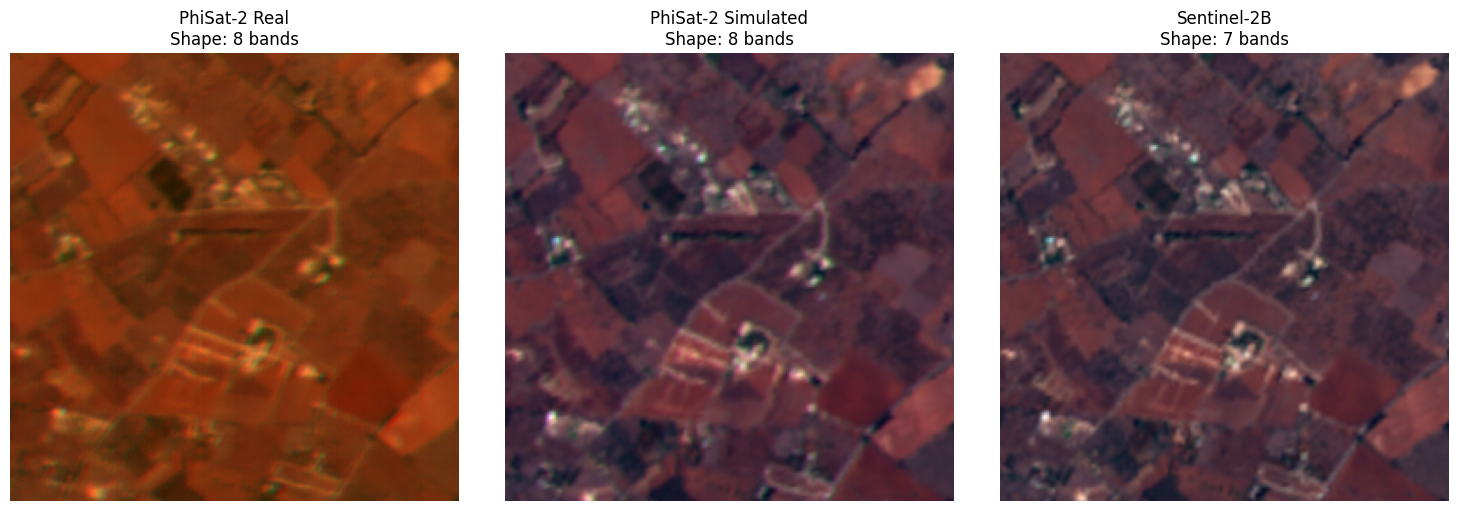

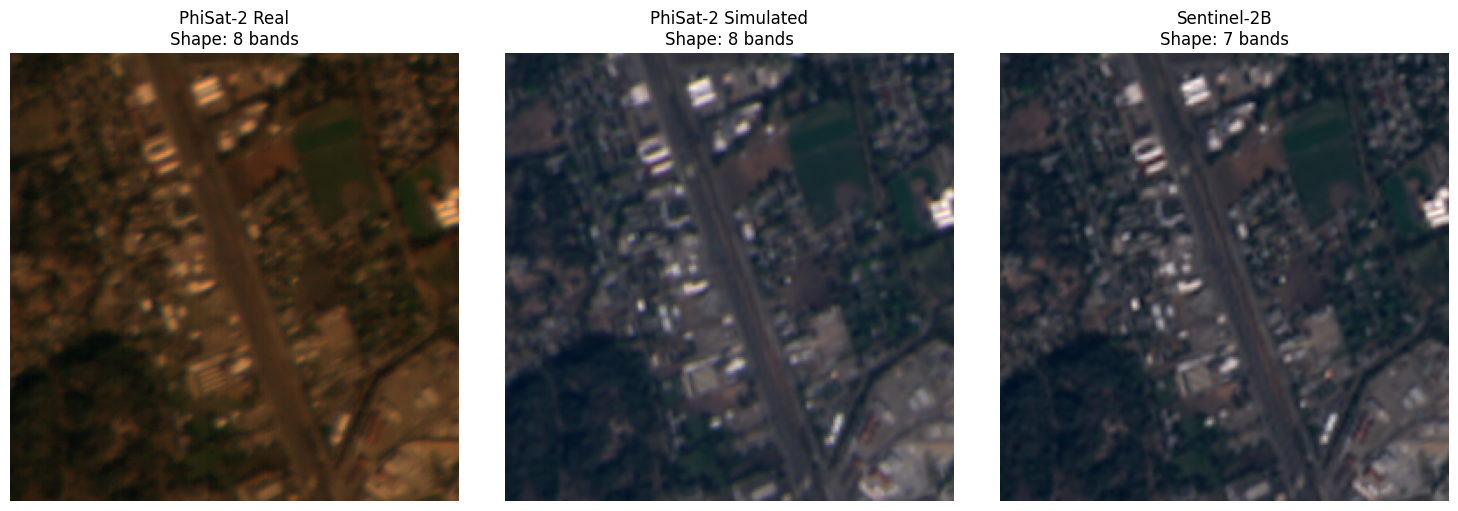

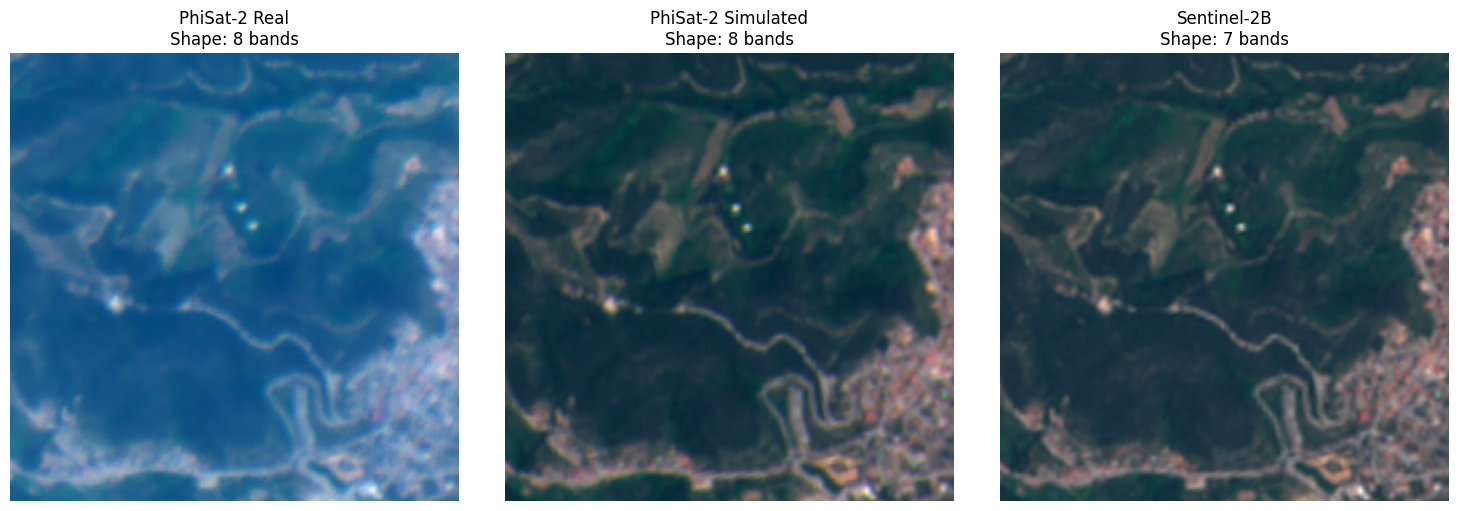

In [ ]:
# Plot the triplets in RGB
def plot_triplet(triplet, idx):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ['PhiSat-2 Real', 'PhiSat-2 Simulated', 'Sentinel-2B']
    
    for i, key in enumerate(['real', 'sim', 's2b']):
        img = triplet[key][idx].numpy()
        
        img_proc = np.sqrt(np.maximum(img, 0))
        
        if key == 'real':
            img_proc = np.clip(img_proc, 0, 38.729)
        elif key == 'sim':
            img_proc = np.clip(img_proc, 0, 100.0)
        else: # s2b
            img_proc = np.clip(img_proc, 0, 100.0)
            
        if key == 's2b':
            # B04(R)=2, B03(G)=1, B02(B)=0
            rgb = np.stack([img_proc[2], img_proc[1], img_proc[0]], axis=-1)
        else:
            # PAN=0, B=1, G=2, R=3
            rgb = np.stack([img_proc[3], img_proc[2], img_proc[1]], axis=-1)

        rgb_min, rgb_max = rgb.min(), rgb.max()
        rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8)
        
        axes[i].imshow(rgb)
        axes[i].set_title(f"{titles[i]}\nShape: {img.shape[0]} bands")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
for idx in range(len(sample_indices)):
    plot_triplet(triplets, idx)

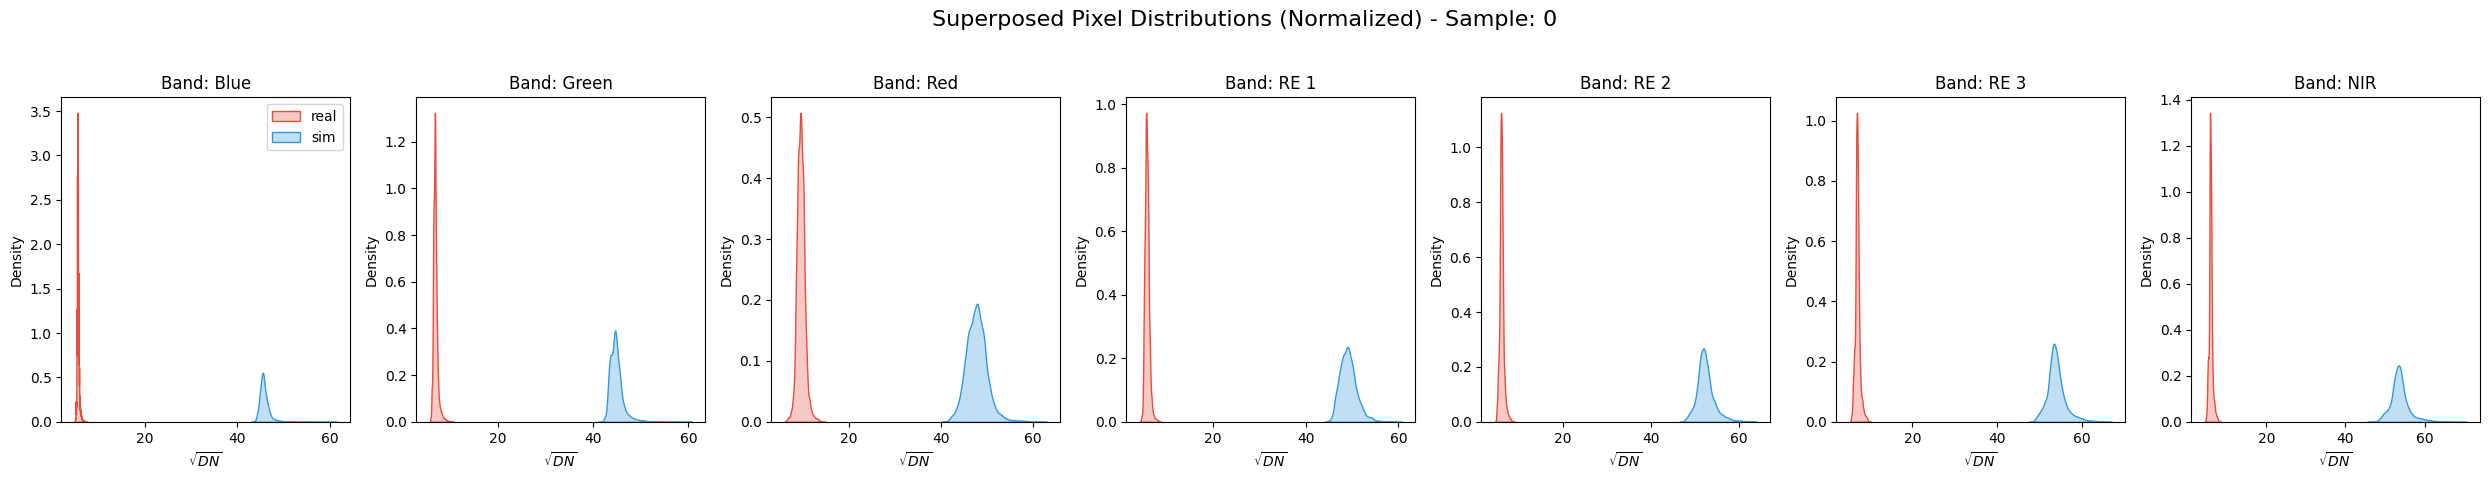

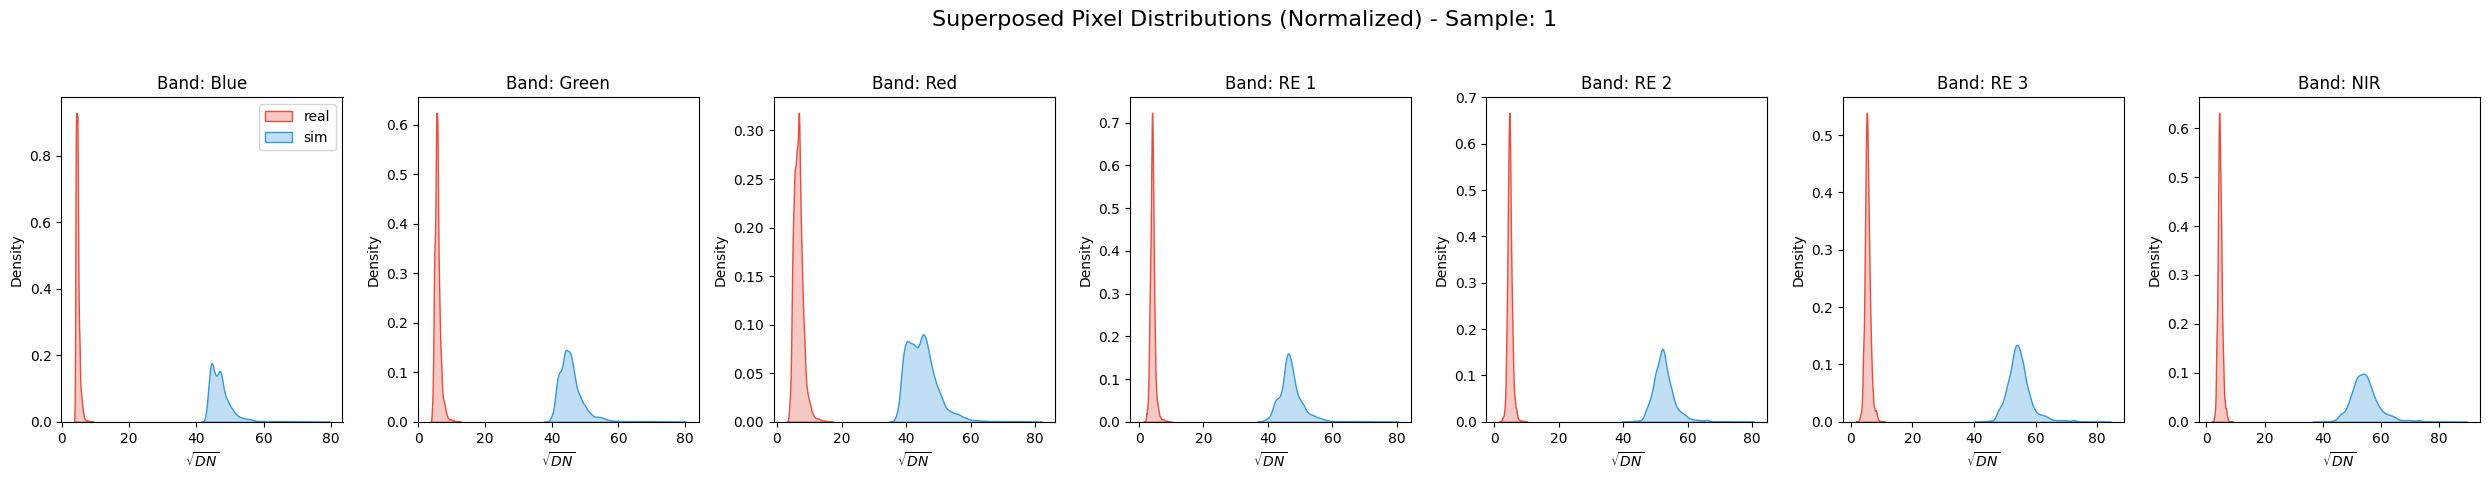

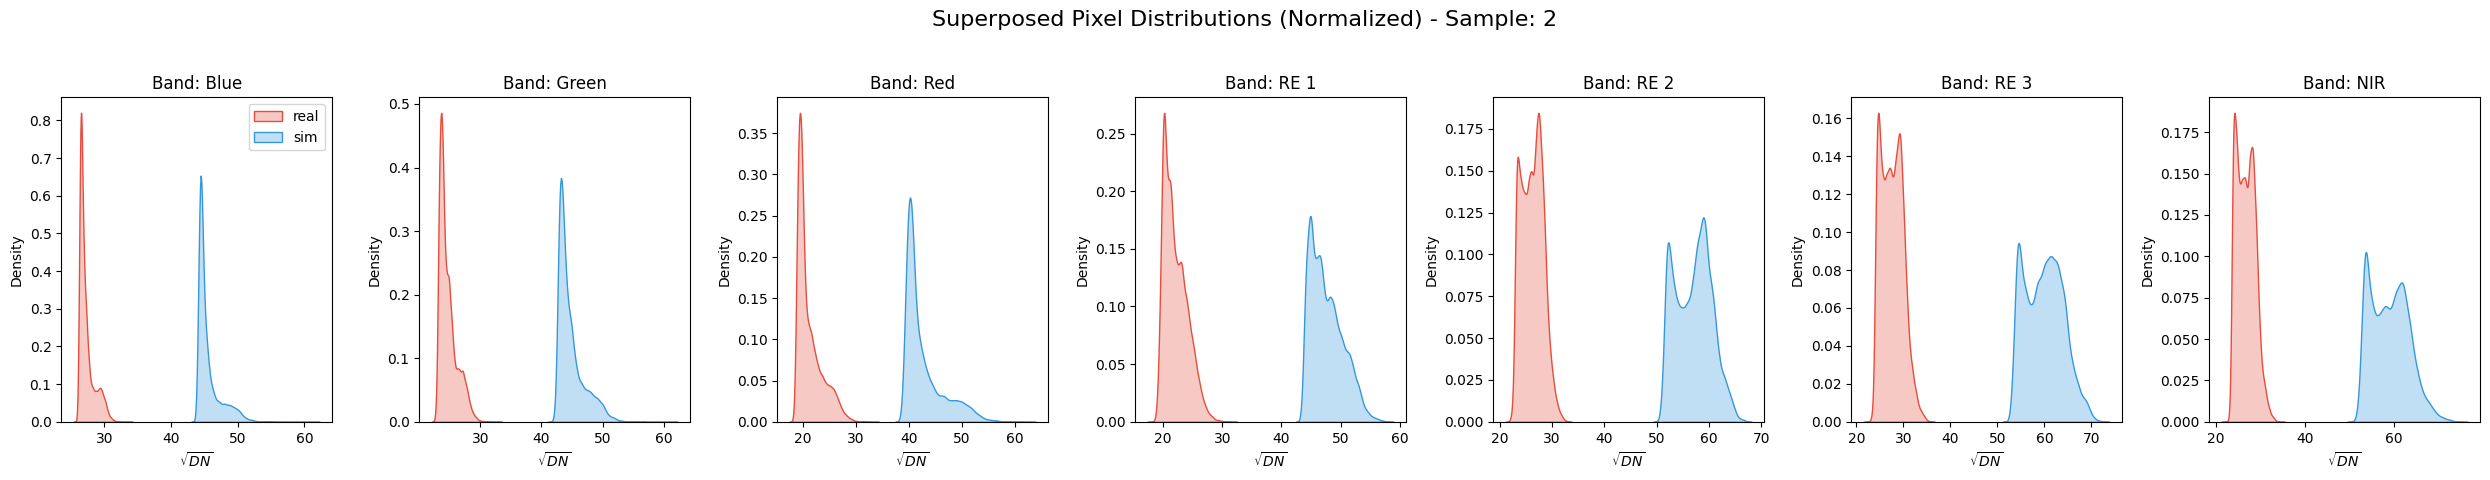

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_superposed_histograms(triplet, idx):
    # On compare les 7 bandes communes (B02 à B08)
    fig, axes = plt.subplots(1, 7, figsize=(25, 5))
    band_names = ['Blue', 'Green', 'Red', 'RE 1', 'RE 2', 'RE 3', 'NIR']
    colors = {'real': '#e74c3c', 'sim': '#3498db', 's2b': '#2ecc71'}
    
    for b in range(7):
        ax = axes[b]
        
        for key in ['real', 'sim']:
            # 1. Alignement des indices
            # S2B commence à 0, PhiSat (real/sim) commence à 1 car index 0 = PAN
            idx_band = b if key == 's2b' else b + 1
            data = triplet[key][idx][idx_band].numpy().flatten()
            
            # 2. Prétraitement recommandé
            # Transformation racine carrée pour normaliser la distribution
            data_proc = np.sqrt(np.maximum(data, 0))
            
            # 3. Clipping physique (98th percentile)
            clip_val = 38.729 if key == 'real' else 100.0
            data_proc = np.clip(data_proc, 0, clip_val)
            
            # 4. Tracé superposé
            sns.kdeplot(
                data_proc, 
                ax=ax, 
                fill=True, 
                color=colors[key], 
                label=key, 
                alpha=0.3
            )
            
        ax.set_title(f"Band: {band_names[b]}")
        ax.set_xlabel("$\sqrt{DN}$")
        if b == 0:
            ax.legend()
            
    plt.suptitle(f"Superposed Pixel Distributions (Normalized) - Sample: {idx}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Exécution
for idx in range(len(sample_indices)):
    plot_superposed_histograms(triplets, idx)

### Cosine similarity function

In [ ]:
def analyze_feature_drift(task, img_s2, img_phisat):
    task.eval()
    with torch.no_grad():
        feat_s2 = task.model.encoder(img_s2)
        feat_phi = task.model.encoder(img_phisat)
        
        similarities = []
        for i, layer in enumerate(layers_to_probe):
            v_s2 = feat_s2[i].flatten(start_dim=1)
            v_phi = feat_phi[i].flatten(start_dim=1)
            
            cos_sim = F.cosine_similarity(v_s2, v_phi).mean().item()
            similarities.append(cos_sim)
            print(f"Couche {layer} - Similarité Cosinus : {cos_sim:.4f}")
            
    return similarities

# Visualisation de la dérive par couche
batch_s2 = triplets['s2b'][0].unsqueeze(0).to(device)  # (1, 7, 256, 256)
# Remove the pan band from the simulated data to match the 7 bands of Sentinel-2B
batch_phi = triplets['real'][0].unsqueeze(0).to(device)[:,1: , :, :]  # (1, 7, 256, 256) en retirant le PAN
print(batch_phi.shape, batch_s2.shape)
sims_data = analyze_feature_drift(task, batch_s2, batch_phi)

torch.Size([1, 7, 256, 256]) torch.Size([1, 7, 256, 256])
Couche 1 - Similarité Cosinus : 0.8911
Couche 3 - Similarité Cosinus : 0.8880
Couche 4 - Similarité Cosinus : 0.8858
Couche 5 - Similarité Cosinus : 0.8821


In [ ]:
import torch
import numpy as np

def get_visualization_data(task, dataloader, device, num_samples=500):
    """
    Extracts embeddings, predictions, and domain labels for t-SNE.
    """
    task.eval()
    all_feats = []
    all_preds = []
    all_domains = []

    count = 0
    with torch.no_grad():
        for batch in dataloader:
            if count >= num_samples:
                break
            
            # 1. Prepare Inputs
            # Assuming triplets dictionary structure from your previous cell
            img_s2 = batch['s2b'].to(device)
            img_phi = batch['real'].to(device)[:, 1:, :, :] # Remove PAN to match S2 (7 bands)
            
            # 2. Extract Latent Features (Embeddings)
            # We take the output of the final encoder layer
            feat_s2 = task.model.encoder(img_s2)[-1]  # Shape: (B, L, D)
            feat_phi = task.model.encoder(img_phi)[-1]
            
            # Global Average Pooling (L, D) -> (D) to get a 1D vector per image
            feat_s2 = feat_s2.mean(dim=1).cpu().numpy()
            feat_phi = feat_phi.mean(dim=1).cpu().numpy()
            
            # 3. Get Task Predictions (e.g., Flood Segmentation/Classification)
            # task(img) returns the model's final output
            out_s2 = task(img_s2).argmax(dim=1).flatten().cpu().numpy()
            out_phi = task(img_phi).argmax(dim=1).flatten().cpu().numpy()
            
            # Store Data
            all_feats.append(feat_s2)
            all_feats.append(feat_phi)
            
            # For y_pred, we take the most frequent class in the patch for visualization 
            # (or use ground truth labels if available)
            all_preds.append(np.repeat(np.bincount(out_s2).argmax(), 1)) 
            all_preds.append(np.repeat(np.bincount(out_phi).argmax(), 1))
            
            # Define Domains
            all_domains.extend(["Sentinel-2"] * img_s2.size(0))
            all_domains.extend(["PhiSat-2 Real"] * img_phi.size(0))
            
            count += img_s2.size(0)

    return (np.concatenate(all_feats), 
            np.array(all_preds), 
            np.array(all_domains))

# --- Execute ---
feats, y_pred, domains = get_visualization_data(task, val_loader, device)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def visualize_latent_space(embeddings, labels, domain_types):
    """
    Applies t-SNE to embeddings and visualizes the clusters.
    
    Args:
        embeddings (np.array): Feature vectors from Terramind (N, D)
        labels (np.array): Class predictions/ground truth (N,)
        domain_types (np.array): 'Simulated' or 'Real' tags (N,)
    """
    # 1. Preprocessing: Standardize features (highly recommended for t-SNE)
    scaler = StandardScaler()
    scaled_embeddings = scaler.fit_transform(embeddings)

    # 2. Apply t-SNE
    print("Running t-SNE... (this may take a minute for large datasets)")
    tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
    embeddings_2d = tsne.fit_transform(scaled_embeddings)

    # 3. Visualization
    plt.figure(figsize=(12, 8))
    
    # We use 'style' for the Domain Gap and 'hue' for the Semantic Class
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1], 
        hue=labels, 
        style=domain_types,
        palette='viridis',
        alpha=0.7,
        s=60
    )

    plt.title("t-SNE Projection: Terramind Latent Space (Sim vs. Real)", fontsize=15)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Class & Domain")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- Example Usage ---
# Assuming 'feats' are your extracted Terramind embeddings:
visualize_latent_space(feats, y_pred, domains)

### mIoU similarity linear probing

In [ ]:
import numpy as np
import seaborn as sns

def plot_similarity_heatmap(feat_s2, feat_phi, layer_idx):
    # Calcul de la similarité cosinus par pixel (dimension Channels)
    # feat shape: [1, C, H, W]
    dot_product = (feat_s2[layer_idx] * feat_phi[layer_idx]).sum(dim=1)
    norm_s2 = torch.norm(feat_s2[layer_idx], dim=1)
    norm_phi = torch.norm(feat_phi[layer_idx], dim=1)
    
    heatmap = (dot_product / (norm_s2 * norm_phi + 1e-8)).squeeze().cpu().numpy()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap, cmap='RdYlGn', center=0.8)
    plt.title(f"Carte de Similarité Spatiale - Couche {layers_to_probe[layer_idx]}")
    plt.show()

In [12]:
plot_similarity_heatmap(task.model.encoder(batch_s2), task.model.encoder(batch_phi), layer_idx=0)

IndexError: Inconsistent shape between the condition and the input (got (384, 1) and (384,))

<Figure size 1000x800 with 0 Axes>

In [ ]:
import pandas as pd

def plot_probing_results(results_df):
    """
    results_df doit contenir colonnes: ['Layer', 'Domain', 'mIoU']
    Domain = ['S2_Normal', 'PhiSat2_Simulated']
    """
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=results_df, x='Layer', y='mIoU', hue='Domain', marker='o', linewidth=2.5)
    plt.axhline(y=0.5, color='gray', linestyle='--', label='Baseline Chance')
    plt.grid(True, alpha=0.3)
    plt.title("Performance du Linear Probing : S2 vs Φsat-2")
    plt.ylabel("mIoU (Segmentation)")
    plt.xlabel("Indice de la couche du Transformer")
    plt.legend()
    plt.show()

# Cosine similarity function

In [ ]:
from terratorch.models.backbones.terramind.model.terramind_vit import TerraMindViT

model = TerraMindViT(
    img_size=256,
    pretrained=True,
    modalities=["S2L1C"],
    bands={"S2L1C": S2_BANDS},
).to(device)
print("✓ TerraMindViT backbone loaded and moved to device")

## 4. Extract Embeddings from Backbone

In [ ]:
def extract_embeddings(model: SemanticSegmentationTask, images_list: list, device: torch.device):
    """Extract embeddings from model backbone."""
    embeddings = []
    
    with torch.no_grad():
        for img_tensor in images_list:
            # Add batch dimension and send to device
            img_batch = img_tensor.unsqueeze(0).to(device)  # (1, 7, 256, 256)
            
            # Get model output
            output = model.predict_step(img_batch)
            
            # Extract embeddings from the backbone
            # The output contains the segmentation logits, but we want the encoded features
            # For simplicity, we'll use the full output and flatten it
            embedding = output.flatten().cpu().numpy()
            embeddings.append(embedding)
    
    return np.array(embeddings)

# Extract embeddings for all modalities
print("Extracting embeddings from backbone...")
embeddings_real = extract_embeddings(model, triplets['real'], device)
embeddings_sim = extract_embeddings(model, triplets['sim'], device)
embeddings_s2b = extract_embeddings(model, triplets['s2b'], device)

print(f"✓ Real embeddings shape: {embeddings_real.shape}")
print(f"✓ Sim embeddings shape: {embeddings_sim.shape}")
print(f"✓ S2B embeddings shape: {embeddings_s2b.shape}")

Extracting embeddings from backbone...


AttributeError: 'ModelOutput' object has no attribute 'flatten'

## 5. Compute Cosine Similarity

In [ ]:
# Compute pairwise cosine similarities
print("Computing cosine similarities...")

similarities = {}
for i in range(len(sample_indices)):
    # Real vs Simulated
    sim_real_sim = cosine_similarity(
        embeddings_real[i].reshape(1, -1),
        embeddings_sim[i].reshape(1, -1)
    )[0, 0]
    
    # Real vs S2B
    sim_real_s2b = cosine_similarity(
        embeddings_real[i].reshape(1, -1),
        embeddings_s2b[i].reshape(1, -1)
    )[0, 0]
    
    # Simulated vs S2B
    sim_sim_s2b = cosine_similarity(
        embeddings_sim[i].reshape(1, -1),
        embeddings_s2b[i].reshape(1, -1)
    )[0, 0]
    
    similarities[i] = {
        'real-sim': sim_real_sim,
        'real-s2b': sim_real_s2b,
        'sim-s2b': sim_sim_s2b
    }
    
    print(f"\nSample {sample_indices[i]}:")
    print(f"  Real vs Simulated: {sim_real_sim:.4f}")
    print(f"  Real vs S2B:       {sim_real_s2b:.4f}")
    print(f"  Simulated vs S2B:  {sim_sim_s2b:.4f}")

## 6. Visualize Results

In [ ]:
# Create similarity matrix visualization
fig, axes = plt.subplots(1, len(sample_indices), figsize=(5*len(sample_indices), 4))

if len(sample_indices) == 1:
    axes = [axes]

similarity_pairs = ['real-sim', 'real-s2b', 'sim-s2b']

for idx, sample_idx in enumerate(sample_indices):
    # Create matrix for heatmap
    matrix = np.array([
        [1.0, similarities[idx]['real-sim'], similarities[idx]['real-s2b']],
        [similarities[idx]['real-sim'], 1.0, similarities[idx]['sim-s2b']],
        [similarities[idx]['real-s2b'], similarities[idx]['sim-s2b'], 1.0]
    ])
    
    # Plot heatmap
    sns.heatmap(matrix, annot=True, fmt='.4f', cmap='coolwarm', 
                xticklabels=['Real', 'Sim', 'S2B'],
                yticklabels=['Real', 'Sim', 'S2B'],
                vmin=0, vmax=1, ax=axes[idx], cbar=True)
    axes[idx].set_title(f'Sample {sample_idx}\nCosine Similarity')

plt.tight_layout()
plt.show()

# Plot bar chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(similarities))
width = 0.25

real_sim_vals = [similarities[i]['real-sim'] for i in range(len(sample_indices))]
real_s2b_vals = [similarities[i]['real-s2b'] for i in range(len(sample_indices))]
sim_s2b_vals = [similarities[i]['sim-s2b'] for i in range(len(sample_indices))]

ax.bar(x - width, real_sim_vals, width, label='Real vs Simulated', alpha=0.8)
ax.bar(x, real_s2b_vals, width, label='Real vs S2B', alpha=0.8)
ax.bar(x + width, sim_s2b_vals, width, label='Simulated vs S2B', alpha=0.8)

ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_title('Embedding Similarity Across Triplets', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'S{idx}' for idx in sample_indices])
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## 7. Summary Statistics

In [ ]:
# Summary statistics
all_real_sim = [similarities[i]['real-sim'] for i in range(len(sample_indices))]
all_real_s2b = [similarities[i]['real-s2b'] for i in range(len(sample_indices))]
all_sim_s2b = [similarities[i]['sim-s2b'] for i in range(len(sample_indices))]

print("\n" + "="*60)
print("EMBEDDING SIMILARITY SUMMARY")
print("="*60)

print(f"\nReal vs Simulated:")
print(f"  Mean: {np.mean(all_real_sim):.4f} ± {np.std(all_real_sim):.4f}")
print(f"  Min/Max: {np.min(all_real_sim):.4f} / {np.max(all_real_sim):.4f}")

print(f"\nReal vs S2B:")
print(f"  Mean: {np.mean(all_real_s2b):.4f} ± {np.std(all_real_s2b):.4f}")
print(f"  Min/Max: {np.min(all_real_s2b):.4f} / {np.max(all_real_s2b):.4f}")

print(f"\nSimulated vs S2B:")
print(f"  Mean: {np.mean(all_sim_s2b):.4f} ± {np.std(all_sim_s2b):.4f}")
print(f"  Min/Max: {np.min(all_sim_s2b):.4f} / {np.max(all_sim_s2b):.4f}")

print("\n" + "="*60)

# Close dataset
f.close()
print("✓ HDF5 file closed")